This notebook is about Adaboost algorithm for regression.

In [88]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [89]:
df=pd.read_csv("cardekho.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [90]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00
mean,9811.86,6.04,55616.48,19.70,1486.06,100.59,5.33,774971.12
std,5643.42,3.01,51618.55,4.17,521.11,42.97,0.81,894128.36
min,0.00,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4906.50,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,9872.00,6.00,50000.00,19.67,1248.00,88.50,5.00,556000.00
75%,14668.50,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,19543.00,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [92]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [93]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [94]:
df['seats'].value_counts()

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64

In [95]:
df[df.duplicated()] #duplicated rows mean the rows which are exactly same as other rows.

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
197,Honda City,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
360,Maruti Baleno,Maruti,Baleno,2,5000,Individual,Petrol,Automatic,21.40,1197,83.10,5,686000
1353,Maruti Swift Dzire,Maruti,Swift Dzire,4,50000,Individual,Diesel,Manual,28.40,1248,74.02,5,680000
1429,Maruti Wagon R,Maruti,Wagon R,13,100000,Individual,Petrol,Manual,18.90,1061,67.00,5,150000
1485,Hyundai i20,Hyundai,i20,3,50000,Individual,Petrol,Manual,18.60,1197,81.83,5,625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti Swift,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti Wagon R,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata Tiago,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai Grand,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


In [96]:
df=df.drop_duplicates(keep="first",ignore_index=True)
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [97]:
df[df['seats']==0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12504,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [98]:
df.loc[df['seats']==0, "seats"]=5

In [99]:
df['seats'].value_counts()

seats
5    12769
7     1902
8      310
6      125
4       76
9       55
2        7
Name: count, dtype: int64

In [100]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [101]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00
mean,6.04,55639.58,19.70,1486.17,100.61,5.33,774701.45
std,3.02,51766.30,4.17,520.42,42.92,0.81,894676.08
min,0.00,100.00,4.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,559000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


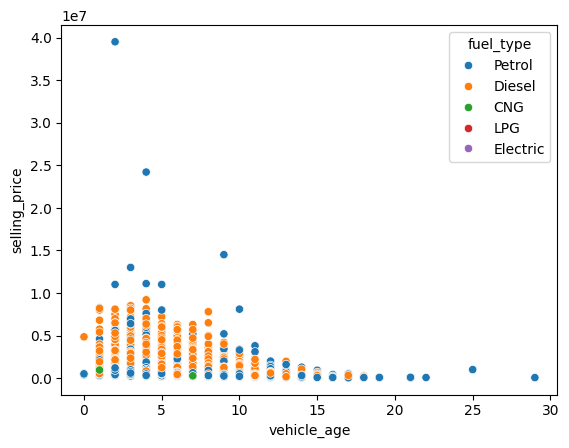

In [102]:
sns.scatterplot(x=df['vehicle_age'], y=df['selling_price'], hue=df['fuel_type'])
plt.show()

In [103]:
df=df[df['selling_price']<15000000]

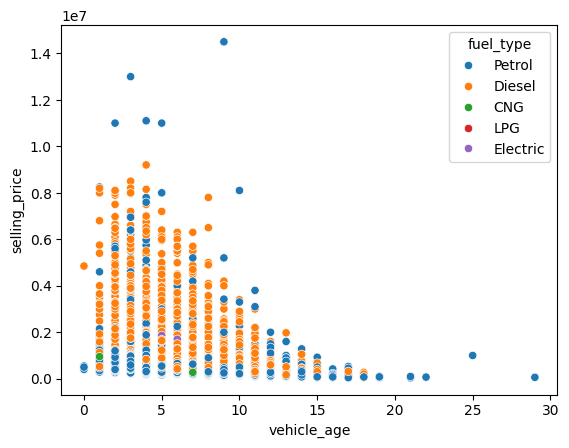

In [104]:
sns.scatterplot(x=df['vehicle_age'], y=df['selling_price'], hue=df['fuel_type'])
plt.show()

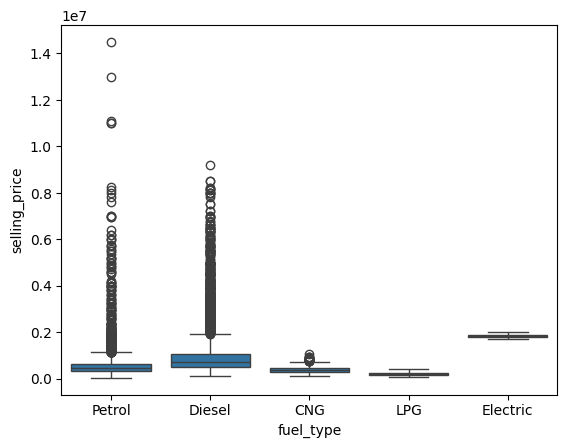

In [105]:
sns.boxplot(data=df, x='fuel_type', y='selling_price')
plt.show()

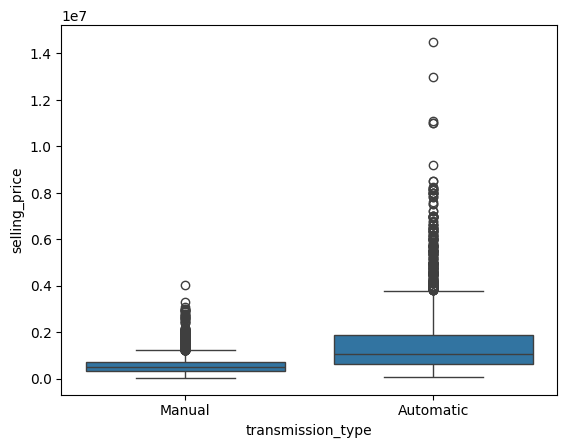

In [106]:
sns.boxplot(data=df, x='transmission_type', y='selling_price')
plt.show()

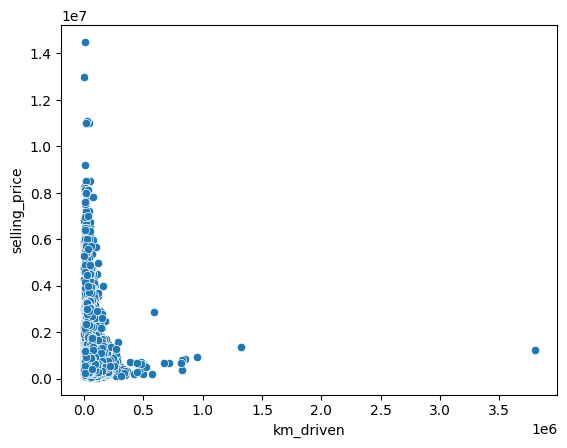

In [107]:
sns.scatterplot(x=df['km_driven'], y=df['selling_price'])
plt.show()

In [108]:
X=df.drop("selling_price", axis=1)
y=df['selling_price']

In [109]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=34)

In [110]:
cat_cols=df.select_dtypes(include='object').columns.to_list()
cat_cols

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [111]:
unique_values=df[cat_cols].nunique()
unique_values

car_name             119
brand                 30
model                118
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [112]:
#seller_type, fuel_type, transmission_type, owner_type, brand, model, location, are the categorical columns. 
#We can use one hot encoding for these columns. But before that we need to check the unique values of these columns. 
#If there are too many unique values, then we can use label encoding instead of one hot encoding.

In [113]:
onehot_columns=['seller_type', 'fuel_type', 'transmission_type']
freg_columns=['car_name', 'brand', 'model']

In [114]:
for col in freg_columns:
    freg=X_train[col].value_counts()/len(X_train)
    X_train[col + '_freg']=X_train[col].map(freg)
    X_test[col + "_freg"]=X_test[col].map(freg)
    mean_freg=freg.mean()
    X_test[col + "_freg"]=X_test[col + "_freg"].fillna(mean_freg)

In [115]:
X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freg,brand_freg,model_freg
6192,Maruti Baleno,Maruti,Baleno,3,33000,Dealer,Petrol,Manual,21.01,1197,81.80,5,0.02,0.33,0.02
4564,Hyundai i10,Hyundai,i10,14,97000,Dealer,Petrol,Manual,20.36,1197,78.90,5,0.03,0.19,0.03
4212,Toyota Innova,Toyota,Innova,5,44236,Dealer,Diesel,Manual,12.99,2494,100.60,7,0.04,0.05,0.04
2531,Maruti Swift,Maruti,Swift,9,120000,Individual,Diesel,Manual,22.90,1248,74.00,5,0.05,0.33,0.05
457,Maruti Swift Dzire,Maruti,Swift Dzire,2,4000,Individual,Petrol,Automatic,21.21,1197,81.80,5,0.06,0.33,0.06


In [116]:
X_train=X_train.drop(["car_name","brand","model"],axis=1)
X_test=X_test.drop(["car_name","brand","model"],axis=1)

In [117]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

transformer=ColumnTransformer(transformers=[("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), onehot_columns)], remainder="passthrough")
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)

In [118]:
encoded_columns=transformer.get_feature_names_out()
encoded_columns

array(['onehot__seller_type_Individual',
       'onehot__seller_type_Trustmark Dealer', 'onehot__fuel_type_Diesel',
       'onehot__fuel_type_Electric', 'onehot__fuel_type_LPG',
       'onehot__fuel_type_Petrol', 'onehot__transmission_type_Manual',
       'remainder__vehicle_age', 'remainder__km_driven',
       'remainder__mileage', 'remainder__engine', 'remainder__max_power',
       'remainder__seats', 'remainder__car_name_freg',
       'remainder__brand_freg', 'remainder__model_freg'], dtype=object)

In [119]:
X_train=pd.DataFrame(X_train, columns=encoded_columns)
X_test=pd.DataFrame(X_test, columns=encoded_columns)
X_train.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_Electric,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freg,remainder__brand_freg,remainder__model_freg
0,0.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,33000.00,21.01,1197.00,81.80,5.00,0.02,0.33,0.02
1,0.00,0.00,0.00,0.00,0.00,1.00,1.00,14.00,97000.00,20.36,1197.00,78.90,5.00,0.03,0.19,0.03
2,0.00,0.00,1.00,0.00,0.00,0.00,1.00,5.00,44236.00,12.99,2494.00,100.60,7.00,0.04,0.05,0.04
3,1.00,0.00,1.00,0.00,0.00,0.00,1.00,9.00,120000.00,22.90,1248.00,74.00,5.00,0.05,0.33,0.05
4,1.00,0.00,0.00,0.00,0.00,1.00,0.00,2.00,4000.00,21.21,1197.00,81.80,5.00,0.06,0.33,0.06


In [120]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10669 entries, 0 to 10668
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   onehot__seller_type_Individual        10669 non-null  float64
 1   onehot__seller_type_Trustmark Dealer  10669 non-null  float64
 2   onehot__fuel_type_Diesel              10669 non-null  float64
 3   onehot__fuel_type_Electric            10669 non-null  float64
 4   onehot__fuel_type_LPG                 10669 non-null  float64
 5   onehot__fuel_type_Petrol              10669 non-null  float64
 6   onehot__transmission_type_Manual      10669 non-null  float64
 7   remainder__vehicle_age                10669 non-null  float64
 8   remainder__km_driven                  10669 non-null  float64
 9   remainder__mileage                    10669 non-null  float64
 10  remainder__engine                     10669 non-null  float64
 11  remainder__max_

In [121]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

In [122]:
model=AdaBoostRegressor()
model.fit(X_train, y_train) 
y_pred=model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 333629.27041882824
Mean Squared Error: 186660378913.50824
R2 Score: 0.6863543562016619


In [123]:
#hyperparameter tuning
params={
    "n_estimators":[50,80,100,200],
    "learning_rate":[0.001,0.01,0.1,1.0,2.0],
    "loss":["linear", "square", "exponential"]
}

In [124]:
rcv=RandomizedSearchCV(estimator=AdaBoostRegressor(), param_distributions=params,scoring='r2', cv=5)
rcv.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.001, 0.01, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 80, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default va

In [125]:
rcv.best_params_

{'n_estimators': 200, 'loss': 'exponential', 'learning_rate': 0.01}

In [126]:
y_pred=rcv.predict(X_test)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 221003.88534853602
Mean Squared Error: 129790940002.58473
R2 Score: 0.7819121381127969


In [131]:
params={
    "estimator__max_depth":[3,4,5],
    "n_estimators":[50,80,100,200],
    "learning_rate":[0.001,0.01,0.1,1.0,2.0],
    "loss":["linear", "square", "exponential"]
}

In [132]:
rcv2=RandomizedSearchCV(estimator=AdaBoostRegressor(DecisionTreeRegressor()), param_distributions=params,scoring='r2', cv=5)
rcv2.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegre...eeRegressor())
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__max_depth': [3, 4, ...], 'learning_rate': [0.001, 0.01, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 80, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [133]:
rcv2.best_params_

{'n_estimators': 200,
 'loss': 'linear',
 'learning_rate': 0.1,
 'estimator__max_depth': 5}

In [135]:
y_pred=rcv2.predict(X_test)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 142846.252488603
Mean Squared Error: 64373758489.98879
R2 Score: 0.8918327014932994
